In [39]:
!pip install langchain-groq


In [40]:
from google.colab import userdata
groq_api_key=userdata.get("GROQ_API_KEY")
from langchain_groq import ChatGroq
llm = ChatGroq(
    groq_api_key=groq_api_key,
    model="llama-3.3-70b-versatile",
    temperature=0.7,
)

In [41]:
from langchain_core.messages import HumanMessage, AIMessage
llm.invoke([HumanMessage(content="I want to know the meaning of water ")]).content #the message is human message

"A simple yet profound question!\n\nWater is a chemical compound made up of two hydrogen atoms and one oxygen atom, with the molecular formula H2O. It's a clear, colorless, odorless, and tasteless liquid that's essential for life on Earth.\n\nBut the meaning of water goes beyond its chemical composition. Water has numerous symbolic, cultural, and practical significance across various aspects of human life. Here are a few examples:\n\n1. **Life and sustenance**: Water is necessary for human survival, as it makes up approximately 60% of our bodies. It's essential for drinking, cooking, and hygiene.\n2. **Nature and environment**: Water is a vital component of the Earth's ecosystem, playing a crucial role in shaping our planet's geology, climate, and weather patterns.\n3. **Spirituality and culture**: Water has spiritual and cultural significance in many societies, often representing purification, renewal, and transformation. For example, baptism in Christianity, the Ganges River in Hindu

In [42]:
from typing import TypedDict,List,Annotated
from operator import add
class graph_schema(TypedDict):
  messages_manual:List
  # using reducer or built in method in LanGraph
  messages_auto: Annotated[List,add]

In [43]:
def create_post(state:graph_schema)-> graph_schema:


  messages_manual=state['messages_manual'] # storing only the human message

  #As we need both human message and Ai message
  response_manual= llm.invoke(messages_manual).content
  response_manual_ai=AIMessage(content=response_manual)

  #now append two messsgaes human and AI
  state['messages_manual']=messages_manual+[response_manual_ai]
  #or
  #state['messages_manual'].append(response_manual_ai)


  #FOR BUILT IN METHOD
  messages_auto= state['messages_auto']
  response_auto= llm.invoke(messages_auto).content
  response_auto_ai=AIMessage(content=response_auto)
  # in above manual we manually added or combine things but here
  state['messages_auto']=[response_auto_ai] #  IT will not update it in place of the first thing ,it will simple automatically add this thing(response_auto_ai) to the existing messages key (messages_auto)
  # but the automated is hard to readilability so I prefer manual

  return state

def curate_post(state:graph_schema)-> graph_schema:

  messages_manual=state['messages_manual']# here now store human messages + Ai messages
  response_manual= llm.invoke(messages_manual).content
  response_manual_ai=AIMessage(content=response_manual)
  state['messages_manual']=messages_manual+[response_manual_ai]#now append two messsgaes human and AI
  #or
  #state['messages_manual'].append(response_manual_ai)


  #FOR BUILT IN METHOD
  messages_auto= state['messages_auto']
  response_auto= llm.invoke(messages_auto).content
  response_auto_ai=AIMessage(content=response_auto)
  # in above manual we manually added or combine things but here
  state['messages_auto']=[response_auto_ai] #  IT will not update it in place of the first thing ,it will simple automatically add this thing(response_auto_ai) to the existing messages key (messages_auto)
  # but the automated is hard to readilability so I prefer manual


  return state


# After the nodes creation create the graph

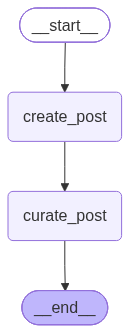

In [44]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(graph_schema)
graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)

#compile the graph
messages_graph=graph.compile()

from IPython.display import Image,display
Image(messages_graph.get_graph().draw_mermaid_png())

In [46]:

messages_graph.invoke(
    {"messages_manual": [HumanMessage(content="The importance of data privacy in the digital age")],
     "messages_auto": [HumanMessage(content="The importance of data privacy in the digital age")]}
)

{'messages_manual': [HumanMessage(content='The importance of data privacy in the digital age', additional_kwargs={}, response_metadata={}),
  AIMessage(content="The importance of data privacy in the digital age cannot be overstated. With the increasing amount of personal data being collected, stored, and shared online, it is essential to ensure that this data is protected from unauthorized access, misuse, and exploitation. Here are some reasons why data privacy is crucial in the digital age:\n\n1. **Protection from Identity Theft**: Personal data, such as social security numbers, credit card numbers, and addresses, can be used to commit identity theft. If this data falls into the wrong hands, it can lead to financial loss, damage to credit scores, and emotional distress.\n2. **Prevention of Cybercrime**: Data breaches can lead to cybercrime, such as phishing, ransomware, and malware attacks. These attacks can compromise sensitive information, disrupt business operations, and cause sign

## in above we can see three message human messages ,Ai message (create_post) and Ai message(curate post) message for  message_manual


## and the other three message message_auto has the same three things (human message , AI message ,Ai message (more perfect))